In [8]:
import numpy as np

In [9]:
nu_min = 1280
nu_max = 1530
n_comp = 11


In [10]:
np.linspace(nu_min , nu_max , n_comp)


array([1280., 1305., 1330., 1355., 1380., 1405., 1430., 1455., 1480.,
       1505., 1530.])

In [11]:
import pandas as pd
import numpy as np
from scipy.constants import c  # Exact speed of light in vacuum (299792458.0 m/s)

# Constants
baseline = 400 # Maximum baseline in meters
freq_MHz = np.linspace(1280, 1530, 9)

# Calculate FWHM in radians (FWHM ~ lambda / B)
fwhm_rad = (c / (freq_MHz * 1e6)) / baseline

# Convert FWHM to arcseconds
fwhm_arcsec = fwhm_rad * (180.0 / np.pi) * 3600.0

# Convert FWHM to Gaussian standard deviation (sigma)
# FWHM = 2 * sqrt(2 * ln(2)) * sigma ≈ 2.355 * sigma
sigma_arcsec = fwhm_arcsec / (2.0 * np.sqrt(2.0 * np.log(2.0)))

# Beam separation: 1 arcmin = 60 arcsec (to keep units consistent with sigma/fwhm)
beam_sep_arcsec = 60.0

# Create dataframe
df_dsa = pd.DataFrame({
    'freq_MHz': freq_MHz,
    'sigma_x': sigma_arcsec,
    'sigma_y': sigma_arcsec,
    'sigma_avg': sigma_arcsec,
    'fwhm_x': fwhm_arcsec,
    'fwhm_y': fwhm_arcsec,
    'fwhm_avg': fwhm_arcsec,
    'beam_sep': beam_sep_arcsec
})

# Save to CSV
csv_filename = "DSA110_beam_parameters.csv"
df_dsa.to_csv(csv_filename, index=False)

print(f"Saved DSA-110 coherent beam parameters to {csv_filename}")



Saved DSA-110 coherent beam parameters to DSA110_beam_parameters.csv


Plotting for Frequency: 1405.00 MHz
Sigma: 46.73 arcsec | Beam Separation: 60.00 arcsec


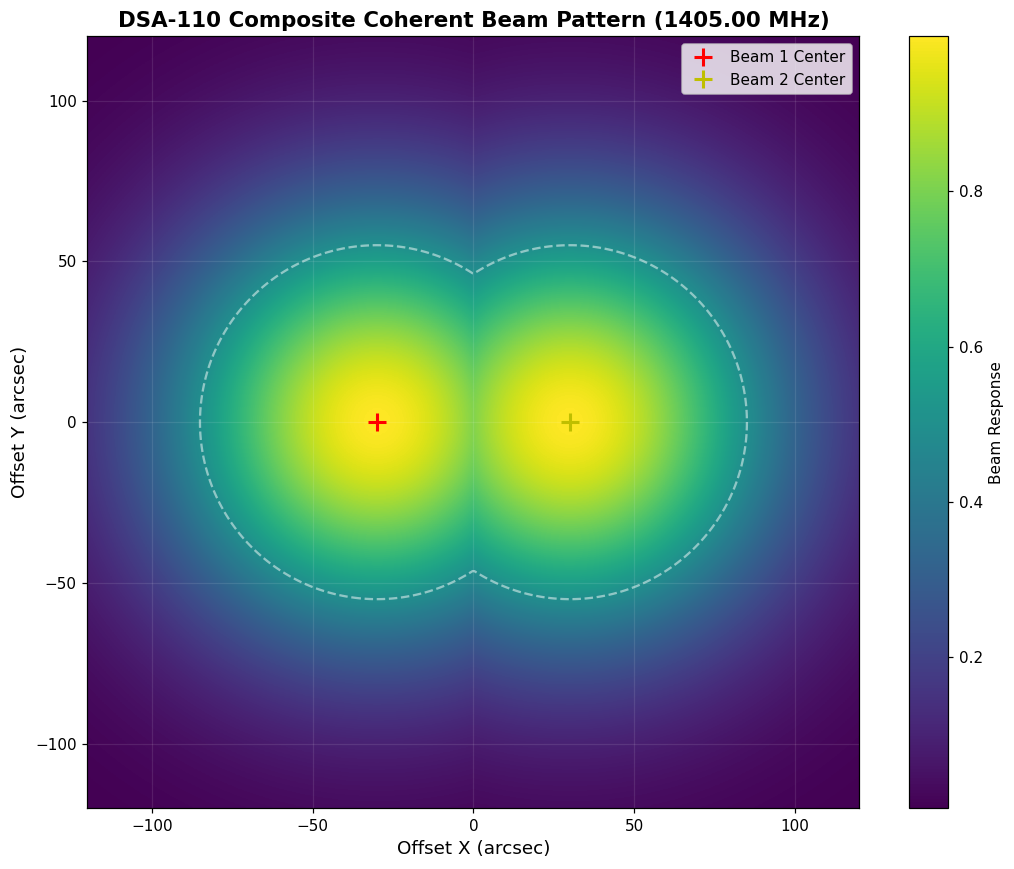

In [12]:
import matplotlib.pyplot as plt

# 1. Select the middle frequency parameters for the plot
idx = len(df_dsa) // 2
sigma_x = df_dsa['sigma_x'].iloc[idx]
sigma_y = df_dsa['sigma_y'].iloc[idx]
beam_sep = df_dsa['beam_sep'].iloc[idx]
freq_plot = df_dsa['freq_MHz'].iloc[idx]

print(f"Plotting for Frequency: {freq_plot:.2f} MHz")
print(f"Sigma: {sigma_x:.2f} arcsec | Beam Separation: {beam_sep:.2f} arcsec")

# 2. Create a 2D spatial grid in arcseconds
extent_arcsec = 120  # Map limits: -120 to +120 arcsec
n_pixels = 400
x = np.linspace(-extent_arcsec, extent_arcsec, n_pixels)
y = np.linspace(-extent_arcsec, extent_arcsec, n_pixels)
X, Y = np.meshgrid(x, y)

# 3. Define centers for two adjacent beams
beam1_cx, beam1_cy = -beam_sep / 2, 0.0
beam2_cx, beam2_cy =  beam_sep / 2, 0.0

# 4. Calculate the 2D Gaussian response for both beams
beam1_resp = np.exp(-0.5 * (((X - beam1_cx) / sigma_x)**2 + ((Y - beam1_cy) / sigma_y)**2))
beam2_resp = np.exp(-0.5 * (((X - beam2_cx) / sigma_x)**2 + ((Y - beam2_cy) / sigma_y)**2))

# 5. Create the composite pattern (detecting pipeline takes the max SNR across formed beams)
composite_beam = np.maximum(beam1_resp, beam2_resp)

# 6. Plotting
fig, ax = plt.subplots(figsize=(10, 8), dpi=110)

# Use extent to map pixels directly to our physical arcsecond grid
im = ax.imshow(composite_beam, origin='lower', cmap='viridis', 
               extent=[-extent_arcsec, extent_arcsec, -extent_arcsec, extent_arcsec])

plt.colorbar(im, ax=ax, label='Beam Response')

# Mark the exact center of each tied-array beam
ax.plot(beam1_cx, beam1_cy, 'r+', markersize=12, markeredgewidth=2, label='Beam 1 Center')
ax.plot(beam2_cx, beam2_cy, 'y+', markersize=12, markeredgewidth=2, label='Beam 2 Center')

# Add 50% response contour lines to show the FWHM boundaries
ax.contour(X, Y, composite_beam, levels=[0.5], colors='white', alpha=0.5, linestyles='dashed')

ax.set_xlabel('Offset X (arcsec)', fontsize=12)
ax.set_ylabel('Offset Y (arcsec)', fontsize=12)
ax.set_title(f'DSA-110 Composite Coherent Beam Pattern ({freq_plot:.2f} MHz)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(color='white', alpha=0.1)

plt.tight_layout()
plt.show()

In [13]:
D = 4.65
fwhm = (1.22 * c / 1350e6 / D) * 180 / np.pi
print(fwhm)
df_dsa = pd.read_csv('DSA110_beam_parameters.csv')

3.338231451910578


=== FRB SIMULATION RESULTS ===
Box Limits X : [-30.00, 30.00] arcsec (beam sep = 60.0 arcsec)
Box Limits Y : [-55.01, 55.01] arcsec (coherent beam FWHM = 110.03 arcsec)
Random FRB Location  : X = 27.48, Y = 22.02 arcsec
Distance to Closest Beam : 22.17 arcsec
Beam Response (to closest beam): 0.893568



/tmp/ipykernel_1013310/1646947300.py:62: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X_grid, Y_grid, beam1_resp, levels=[0.5], colors='blue', alpha=0.8, linewidths=2.5, label='Beam 1 FWHM')
/tmp/ipykernel_1013310/1646947300.py:63: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X_grid, Y_grid, beam2_resp, levels=[0.5], colors='cyan', alpha=0.8, linewidths=2.5, label='Beam 2 FWHM')


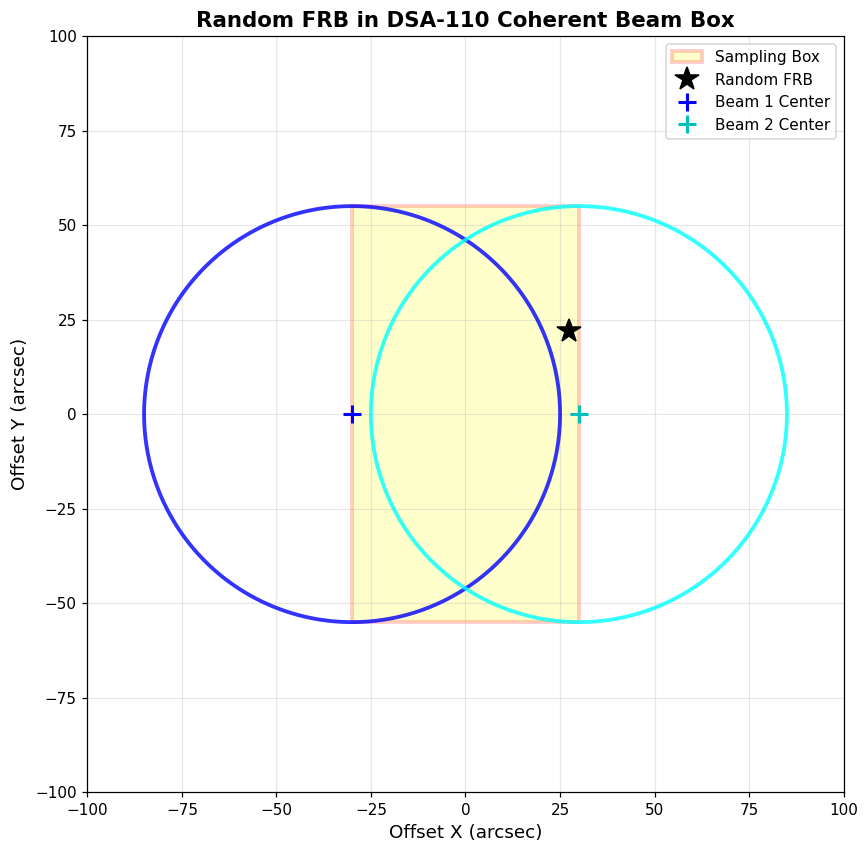

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. Grab parameters from the previous cells (using middle frequency)
idx = len(df_dsa) // 2
sigma_arcsec = df_dsa['sigma_avg'].iloc[idx]
fwhm_coherent_arcsec = df_dsa['fwhm_avg'].iloc[idx]
beam_sep_arcsec = df_dsa['beam_sep'].iloc[idx]

# 2. Define the Sampling Box Bounds
# X spans the beam separation width (e.g. -30 to +30 arcsec for 1 arcmin = 60 arcsec)
x_min, x_max = -beam_sep_arcsec / 2.0, beam_sep_arcsec / 2.0
# Y spans the COHERENT beam height (not primary beam)
y_min, y_max = -fwhm_coherent_arcsec / 2.0, fwhm_coherent_arcsec / 2.0

# 3. Generate a random FRB position inside the box
# np.random.seed(42)  # For reproducibility
frb_x = np.random.uniform(x_min, x_max)
frb_y = np.random.uniform(y_min, y_max)

# 4. Calculate Coherent Beam Response to closest beam
# Two beams separated by beam_sep in X direction
beam1_cx, beam1_cy = -beam_sep_arcsec / 2.0, 0.0
beam2_cx, beam2_cy =  beam_sep_arcsec / 2.0, 0.0

# Distance to each beam center
dist_to_beam1 = np.sqrt((frb_x - beam1_cx)**2 + (frb_y - beam1_cy)**2)
dist_to_beam2 = np.sqrt((frb_x - beam2_cx)**2 + (frb_y - beam2_cy)**2)

# Beam responses (2D Gaussian)
response_beam1 = np.exp(-0.5 * (dist_to_beam1 / sigma_arcsec)**2)
response_beam2 = np.exp(-0.5 * (dist_to_beam2 / sigma_arcsec)**2)

# Closest beam and its response
closest_dist = min(dist_to_beam1, dist_to_beam2)
closest_response = max(response_beam1, response_beam2)

print("=== FRB SIMULATION RESULTS ===")
print(f"Box Limits X : [{x_min:.2f}, {x_max:.2f}] arcsec (beam sep = {beam_sep_arcsec:.1f} arcsec)")
print(f"Box Limits Y : [{y_min:.2f}, {y_max:.2f}] arcsec (coherent beam FWHM = {fwhm_coherent_arcsec:.2f} arcsec)")
print(f"Random FRB Location  : X = {frb_x:.2f}, Y = {frb_y:.2f} arcsec")
print(f"Distance to Closest Beam : {closest_dist:.2f} arcsec")
print(f"Beam Response (to closest beam): {closest_response:.6f}")
print("==============================\n")

# 5. Create 2D spatial grid for contours
extent_arcsec = 100
n_pixels = 300
x_grid = np.linspace(-extent_arcsec, extent_arcsec, n_pixels)
y_grid = np.linspace(-extent_arcsec, extent_arcsec, n_pixels)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Calculate 2D Gaussian response for both beams
beam1_resp = np.exp(-0.5 * (((X_grid - beam1_cx) / sigma_arcsec)**2 + ((Y_grid - beam1_cy) / sigma_arcsec)**2))
beam2_resp = np.exp(-0.5 * (((X_grid - beam2_cx) / sigma_arcsec)**2 + ((Y_grid - beam2_cy) / sigma_arcsec)**2))

# 6. Plot
fig, ax = plt.subplots(figsize=(8, 12), dpi=110)

# Plot only the FWHM (0.5 response level) contour for both beams
ax.contour(X_grid, Y_grid, beam1_resp, levels=[0.5], colors='blue', alpha=0.8, linewidths=2.5, label='Beam 1 FWHM')
ax.contour(X_grid, Y_grid, beam2_resp, levels=[0.5], colors='cyan', alpha=0.8, linewidths=2.5, label='Beam 2 FWHM')

# Plot the sampling box
box = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                linewidth=2.5, edgecolor='red', facecolor='yellow', alpha=0.2, label='Sampling Box')
ax.add_patch(box)

# Plot the FRB
ax.plot(frb_x, frb_y, 'k*', markersize=16, label='Random FRB', zorder=5)

# Plot beam centers
ax.plot(beam1_cx, beam1_cy, 'b+', markersize=12, markeredgewidth=2, label='Beam 1 Center')
ax.plot(beam2_cx, beam2_cy, 'c+', markersize=12, markeredgewidth=2, label='Beam 2 Center')

# Formatting - Y axis spans from bottom to top of coherent beam
ax.set_aspect('equal')
ax.set_xlim(-extent_arcsec, extent_arcsec)
ax.set_ylim(-extent_arcsec, extent_arcsec)
ax.set_xlabel('Offset X (arcsec)', fontsize=12)
ax.set_ylabel('Offset Y (arcsec)', fontsize=12)
ax.set_title('Random FRB in DSA-110 Coherent Beam Box', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()